# #snOMG
## Written By Jared Rennie (@jjrennie)

Have you wondered how much snow occurred on a certain date (or range of dates?) This notebook will help you answer that question. We will be using data from <a href='http://www.ncei.noaa.gov' target='_blank'> NOAA's National Centers of Environmental Information</a>, specifically the Global Historical Climatology Network - Daily Dataset: 

- GHCNd Info: https://www.ncei.noaa.gov/products/global-historical-climatology-network-daily
- GHCNd AWS Location: https://registry.opendata.aws/noaa-ghcn/

In order to understand gridded vs observed, we will also look at data from the National Gridded Snowfall Analysis run by the <a href='http://www.nohrsc.noaa.gov' target='_blank'> National Operational Hydrologic Remote Sensing Center (NOHRSC) </a>
- NOHRSC Info: https://www.nohrsc.noaa.gov/snowfall_v2/
- NOHRSC Data: https://www.nohrsc.noaa.gov/snowfall_v2/data

In addition to answering these questions, you will learn how to get data from the cloud (and elsewhere) and plot it, without actually reading in the entire dataset!

## What You Need
First off, the entire codebase works in Python 3. In addition to base Python, you will need the following packages installed: 
- numpy, pandas, and xarray (to slice annd dice the data)
- scipy, geopandas, and rioxarray (to read in some shapefiles and do GIS calculations)
- pyarrow or fastparquet (for the parquet data ingest)
- matplotlib and cartopy (to plot)
  
The "easiest" way is to install these is by installing <a href='https://www.anaconda.com' target="_blank">anaconda</a>, and then applying <a href='https://conda-forge.org/' target="_blank">conda-forge</a>. Afterward, then you can install the above packages. 

## Table of Contents:
* [Importing Packages](#first-bullet)
* [Insert User Arguments](#second-bullet)
* [Part 1: Analysis of In-Situ Observations using GHCNd](#third-bullet)
* [Part 2: Analysis of Gridded Observations using NOHRSC](#fourth-bullet)

### Importing Packages <a class="anchor" id="first-bullet"></a>
Assuming you did the above, it should (in theory) import everything no problem:

In [1]:
%matplotlib inline

# Import Packages
import warnings
warnings.filterwarnings("ignore")

import sys,os,requests
import numpy as np
import numpy.ma as ma
import pandas as pd
import xarray as xr
import rioxarray
import geopandas as gpd
from scipy.interpolate import griddata
import pyarrow.dataset as ds

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader

print("SUCCESS!")

SUCCESS!


If you made it this far, great!

### Insert Arguments <a class="anchor" id="second-bullet"></a>
We need some arguments, including the start date of the snowfall, the end date of the snowfall, and the author of this map. If you only want 1 day of snowfall, make start_date equal end_date.

Example snowstorms are below for you to use, but feel free to add your own!

 **Change the arguments below to your liking**

In [2]:
# Insert Arguments Here
# If plotting for 1 date only, make end_date = to start_date

# April Fools Day Storm of 1997
#start_date='1997-04-01'
#end_date='1997-04-01' 

# Feb 2026 Blizzard 
start_date='2026-02-22'
end_date='2026-02-24' 

# Storm of the Century (1993)
#start_date='1993-03-12'
#end_date='1993-03-14' 

# Jan 1996 Blizzard 
#start_date='1996-01-06'
#end_date='1996-01-08' 

# Jan 1978 Blizzard 
#start_date='1978-01-24'
#end_date='1978-01-29' 

# Feb 1978 Blizzard 
#start_date='1978-02-05'
#end_date='1978-02-07' 

author='NOT JARED RENNIE'

# Part 1: Analysis of In-Situ Observations using GHCNd <a class="anchor" id="third-bullet"></a>

## Get Stations and Associated Metadata
The GHCNd database has over 100,000 stations across the globe, and not all of them report snow or snow depth. We are also only looking at stations in the US and Canada, so we need to filter down the stations we need. This block of code will do that, including getting some metadata we need for plotting later, like latitude, longitude, and state.

Bad news is that GHCNd has 2 metadata files to get this info (don't ask me why) but we will get both files and join everything we need into 1 dataframe.

In [3]:
%%time

#################################
# FILE ONE: GHCNd Station File
stnUrl = "https://noaa-ghcn-pds.s3.amazonaws.com/ghcnd-stations.txt"

# Define the columns we need from the stations file:
# ID: 0-11, STATE: 38-40 (39th-40th character)
station_colspecs = [(0, 11), (38, 40)]
station_colnames = ["ID", "STATE"]

# Read the fixed-width file
ghcn_meta1 = pd.read_fwf(stnUrl, colspecs=station_colspecs, names=station_colnames)

#################################
# FILE TWO: GHCNd Inventory File
invUrl = "https://noaa-ghcn-pds.s3.amazonaws.com/ghcnd-inventory.txt"

# Define column names and widths (fixed-width format)
inventory_colspecs = [(0, 11), (12, 20), (21, 30), (31, 35), (36, 40), (41, 45)]
inventory_colnames = ["ID", "LAT", "LON", "element", "first_year", "last_year"]

# Read the fixed-width file
ghcn_meta2 = pd.read_fwf(invUrl, colspecs=inventory_colspecs, names=inventory_colnames)

#################################
# JOIN
ghcn_meta = ghcn_meta2.merge(ghcn_meta1, on="ID", how="left")
ghcn_meta

CPU times: user 5.15 s, sys: 431 ms, total: 5.58 s
Wall time: 5.97 s


,ID,LAT,LON,element,first_year,last_year,STATE
0,ACW00011604,17.1167,-61.7833,TMAX,1949,1949,NaN
1,ACW00011604,17.1167,-61.7833,TMIN,1949,1949,NaN
2,ACW00011604,17.1167,-61.7833,PRCP,1949,1949,NaN
3,ACW00011604,17.1167,-61.7833,SNOW,1949,1949,NaN
4,ACW00011604,17.1167,-61.7833,SNWD,1949,1949,NaN
...,...,...,...,...,...,...,...
769233,ZI000067983,-20.2000,32.6160,PRCP,1951,2025,NaN
769234,ZI000067983,-20.2000,32.6160,TAVG,1962,2025,NaN
769235,ZI000067991,-22.2170,30.0000,TMAX,1951,1990,NaN
769236,ZI000067991,-22.2170,30.0000,TMIN,1951,1990,NaN


Now we will filter stations so that
- They occurr in the US or Canada 
- They report both Snowfall (SNOW) for the year in question

In [4]:
%%time

inYear=int(start_date[0:4])

# Function to filter out stations to use in project
def get_snow_stations(df, inYear):
    df = df[df["ID"].str.startswith(("US", "CA"))]
    df = df[df["element"].isin(["SNOW"])]
    df = df[(df["first_year"] <= inYear) & (df["last_year"] >= inYear)]
    df = df.drop(['element','first_year','last_year'], axis=1)
    df=df.drop_duplicates(subset="ID").reset_index(drop=True)
    return df
    
# Call Function and print out results
inStns = get_snow_stations(ghcn_meta, inYear)
stations = set(inStns["ID"])
inStns

CPU times: user 77.9 ms, sys: 19.8 ms, total: 97.6 ms
Wall time: 97 ms


,ID,LAT,LON,STATE
0,CA1AB000012,51.0562,-114.1040,AB
1,CA1AB000024,50.5638,-111.8985,AB
2,CA1AB000025,51.0562,-114.1975,AB
3,CA1AB000031,53.5611,-111.8741,AB
4,CA1AB000039,50.6995,-113.4268,AB
...,...,...,...,...
18843,USW00094988,42.1106,-92.9164,IA
18844,USW00094989,41.9906,-93.6186,IA
18845,USW00094991,40.6306,-93.9006,IA
18846,USW00094993,45.6689,-96.9919,SD


### Get Snowfall Data for Day in Question
Now that we have the stations, let's grab the data from AWS. It is in parquet format, which makes it much easer to analyze and filter data, without reading in the whole dataset. The parquet data is organized by element and year, so we will build a dataframe for SNOW. The database also has flags for quality and measurement. We will remove data that failed a quality check, and we will save the measurement flag for later. We will consider trace measurements (Measurement Flag of 'T') as a value available for consideration. 

In [5]:
%%time

# Format dates for selection
target_date1=start_date.replace('-','')
target_date2=end_date.replace('-','')

# Read GHCN daily snowfall data (SNOW) hosted on AWS
dsSnow = ds.dataset(f"s3://noaa-ghcn-pds/parquet/by_year/YEAR={inYear}/ELEMENT=SNOW/",format="parquet")

# Filter out snow values to dates asked
snow_table = dsSnow.to_table(
    filter=(
        ds.field("ID").isin(stations) &
        (ds.field("DATE") >= target_date1) &
        (ds.field("DATE") <= target_date2) &
        ds.field("Q_FLAG").is_null()
    )
)

# Convert to pandas
df = snow_table.to_pandas()

# Sum snowfall (mm) by station, then convert to inches
outSnow = (df.groupby("ID", as_index=False)["DATA_VALUE"].sum().rename(columns={"DATA_VALUE": "SNOW_SUM"}))
outSnow["SNOW_SUM"] *= 0.0393701
outSnow

CPU times: user 200 ms, sys: 18.2 ms, total: 219 ms
Wall time: 645 ms


,ID,SNOW_SUM
0,CA1AB000012,0.000000
1,CA1AB000024,0.000000
2,CA1AB000031,1.417324
3,CA1AB000039,0.000000
4,CA1AB000053,0.000000
...,...,...
13395,USW00094911,0.000000
13396,USW00094949,0.000000
13397,USW00094950,0.000000
13398,USW00094982,0.000000


Let's now join the data and metadata, only consider values greater than 0, then sort to help with plotting

In [6]:
# Join Metadata and Data
finalData = inStns.merge(outSnow, on="ID", how="inner")

# Get Final Values By Criteria
finalData=finalData[(finalData['SNOW_SUM'] > 0)].sort_values(by='SNOW_SUM')
finalData

,ID,LAT,LON,STATE,SNOW_SUM
7274,US1OHSD0002,41.3658,-83.0754,OH,0.039370
3379,US1INMD0047,40.0782,-85.6574,IN,0.078740
10341,US1WIDL0018,43.7921,-88.6166,WI,0.118110
10360,US1WIGL0002,43.8207,-89.0766,WI,0.118110
3383,US1INMG0018,39.6212,-86.3460,IN,0.118110
...,...,...,...,...,...
7808,US1RIKN0083,41.7569,-71.4290,RI,34.015766
7823,US1RIPR0119,41.8422,-71.3471,RI,34.291357
7802,US1RIKN0038,41.7543,-71.3944,RI,37.480335
13205,USW00014765,41.7225,-71.4325,RI,37.913406


Let's find out how many stations are being used, including a breakdown of some of the networks used in GHCNd. This will be helpful later. 

In [7]:
numStns_ALL=len(finalData)

cocorahs = finalData[finalData["ID"].str.startswith(("US1", "CA1"))]
numStns_COCORAHS=len(cocorahs)

coop = finalData[finalData["ID"].str.startswith(("USC", "CAC"))]
numStns_COOP=len(coop)

wban = finalData[finalData["ID"].str.startswith(("USW", "CAW"))]
numStns_WBAN=len(wban)

print("Number of Stations Used: ",numStns_ALL)
print("Number of CoCoRaHS Stations Used: ",numStns_COCORAHS)
print("Number of COOP Stations Used: ",numStns_COOP)
print("Number of WBAN Stations Used: ",numStns_WBAN)

Number of Stations Used:  3023
Number of CoCoRaHS Stations Used:  2222
Number of COOP Stations Used:  708
Number of WBAN Stations Used:  93


Now for the fun part!

## Plot the Data
This block of code plots the data for CONUS, parts of southern Canada, and Alaska.

Feel free to tinker with this block if you want to change colors, or utilize other areas (like all of Canada).

PLOTTING


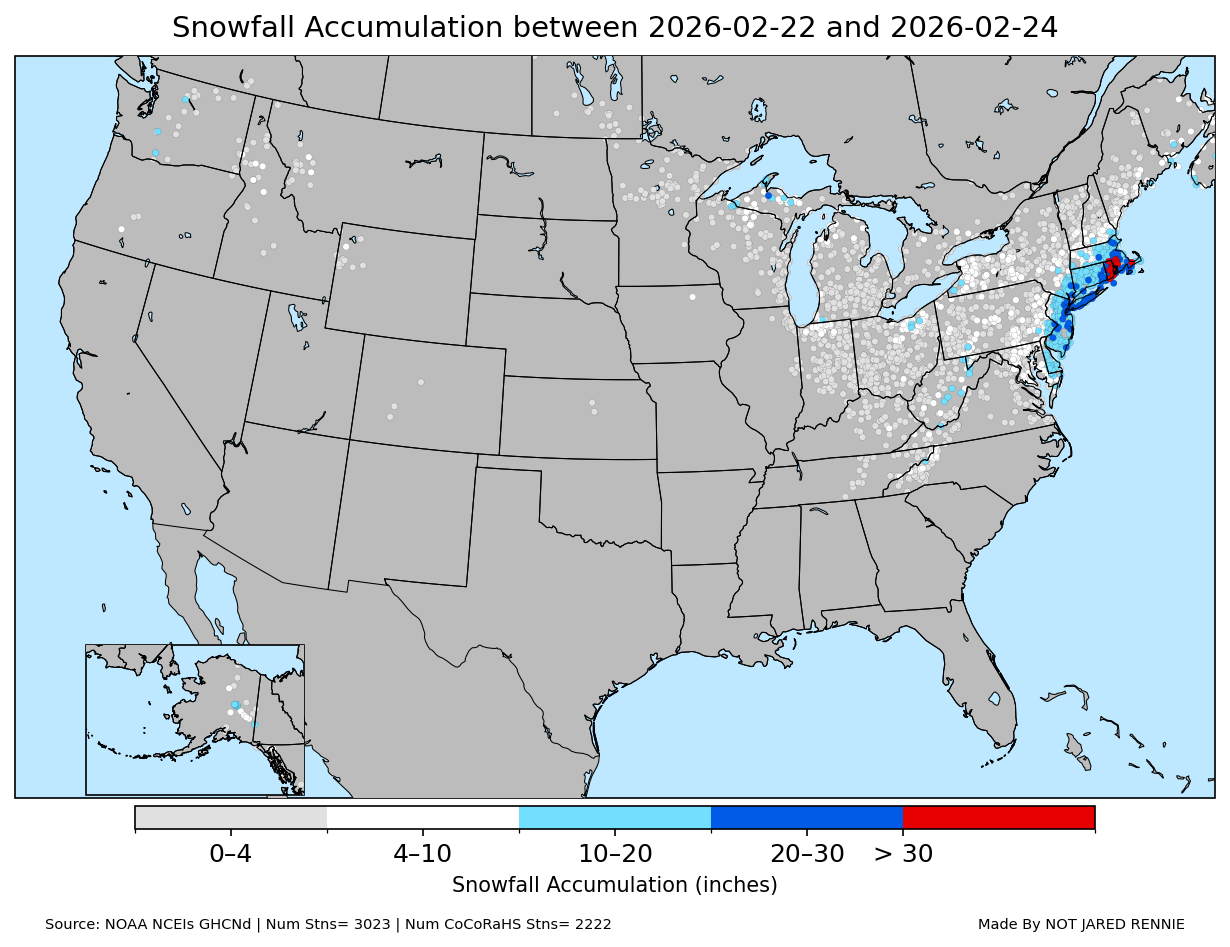

CPU times: user 7.78 s, sys: 102 ms, total: 7.89 s
Wall time: 7.65 s


In [8]:
%%time

print('PLOTTING')

#################################################
# PLOTTING SETTINGS
dpi = 150
land_hex='#bcbcbc'  # ESRI Light Gray Canvas
ocean_hex='#bee8ff' # ESRI Light Gray Canvas
edgecolor = 'black'

if start_date == end_date:
    outTitle = f'Snowfall Accumulation on {end_date}'
else:
    outTitle = f'Snowfall Accumulation between {start_date} and {end_date}'
    
#################################################
# CREATE FIGURE AND AXES
fig = plt.figure(num=1, figsize=(8, 5), dpi=dpi, facecolor='w', edgecolor='k')

# CONUS
conus_ax = fig.add_axes([0, 0, 1, 1], projection=ccrs.LambertConformal())
conus_ax.set_facecolor(ocean_hex)
conus_ax.spines['geo'].set_edgecolor(edgecolor)
conus_ax.set_extent([-120, -73, 22, 50], crs=ccrs.Geodetic())

# ALASKA
ak_ax = fig.add_axes([0.05, 0.01, 0.20, 0.20], projection=ccrs.Orthographic(-133.6667, 57))
ak_ax.set_facecolor(ocean_hex)
ak_ax.spines['geo'].set_edgecolor(edgecolor)
ak_ax.set_extent([-184, -128, 53, 67], crs=ccrs.Geodetic())

# Add Additional Features
conus_ax.add_feature(cfeature.LAND, linewidth=0.5, facecolor=land_hex, edgecolor=edgecolor, zorder=3)
ak_ax.add_feature(cfeature.LAND, linewidth=0.5, facecolor=land_hex, edgecolor=edgecolor, zorder=3)
conus_ax.add_feature(cfeature.LAKES, linewidth=0.5, facecolor=ocean_hex, edgecolor=edgecolor, zorder=4)
conus_ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor=edgecolor, zorder=10)
ak_ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor=edgecolor, zorder=10)

# Define discrete colormap and boundaries
bounds = [0, 4, 10, 20, 30, 1e6]
colors = ["#E1E1E1","#FFFFFF","#72DFFE","#005CE7","#E60100"]
cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# Plot Points (CONUS and AK)
scCONUS = conus_ax.scatter(finalData['LON'],finalData['LAT'],c=finalData['SNOW_SUM'],
                      cmap=cmap,norm=norm,s=10,transform=ccrs.PlateCarree(),edgecolors='black',
                      linewidths=0.05,zorder=9)
scAK = ak_ax.scatter(finalData['LON'],finalData['LAT'],c=finalData['SNOW_SUM'],
                      cmap=cmap,norm=norm,s=10,transform=ccrs.PlateCarree(),edgecolors='black',
                      linewidths=0.05,zorder=9)

# Add legend
cax = fig.add_axes([0.1, -0.035, 0.8, 0.03])
cbar=plt.colorbar(scCONUS, cax=cax,orientation='horizontal',spacing='uniform')
cbar.set_ticks([2, 7, 15, 25, 50])
cbar.set_ticklabels(["0–4","4–10","10–20","20–30","> 30"])
cbar.set_label("Snowfall Accumulation (inches)",size=10)
cbar.ax.tick_params(labelsize=12)

# Add Titles
plt.suptitle(str(outTitle),size=14,color='black',y=1.05)
conus_ax.annotate('Source: NOAA NCEIs GHCNd | Num Stns= '+str(numStns_ALL)+' | Num CoCoRaHS Stns= '+str(numStns_COCORAHS),xy=(0.025, -0.18), xycoords='axes fraction', fontsize=7,color='black',horizontalalignment='left', verticalalignment='bottom')
conus_ax.annotate('Made By '+author,xy=(0.975, -0.18), xycoords='axes fraction', fontsize=7,color='black',horizontalalignment='right', verticalalignment='bottom')
plt.show()

## A brief lesson on interpolation
Let's zoom in on the Northeast US

PLOTTING (Northeast US)


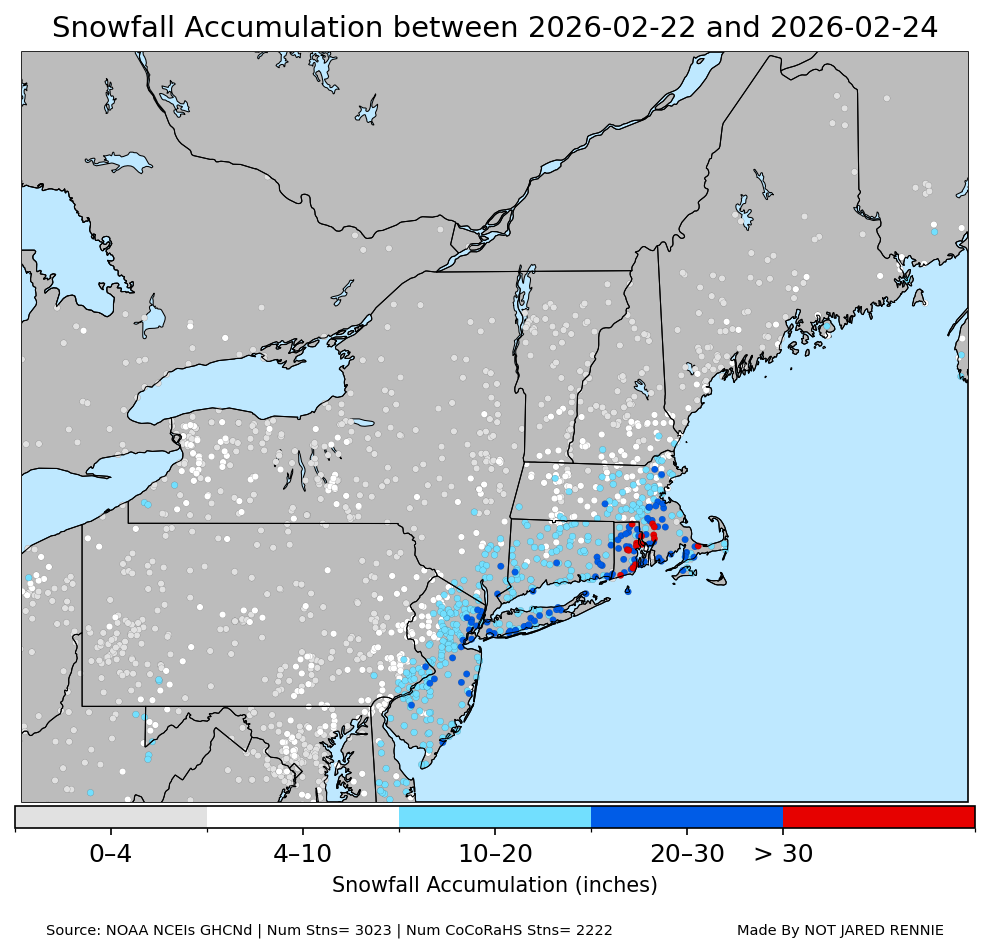

CPU times: user 32.5 s, sys: 215 ms, total: 32.7 s
Wall time: 32.5 s


In [9]:
%%time

# Map extent (Northeast)
lon_min, lon_max = -81.5, -66
lat_min, lat_max = 38.5, 47.5

print('PLOTTING (Northeast US)')

#################################################
# CREATE FIGURE AND AXES
fig = plt.figure(num=1, figsize=(8, 5), dpi=dpi, facecolor='w', edgecolor='k')

# CONUS
conus_ax = fig.add_axes([0, 0, 1, 1], projection=ccrs.Mercator())
conus_ax.set_facecolor(ocean_hex)
conus_ax.spines['geo'].set_edgecolor(edgecolor)
conus_ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.Geodetic())

# Add Additional Features
conus_ax.add_feature(cfeature.LAND, linewidth=0.5, facecolor=land_hex, edgecolor=edgecolor, zorder=3)
conus_ax.add_feature(cfeature.LAKES, linewidth=0.5, facecolor=ocean_hex, edgecolor=edgecolor, zorder=4)
conus_ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor=edgecolor, zorder=10)

# Plot Points
scCONUS = conus_ax.scatter(finalData['LON'],finalData['LAT'],c=finalData['SNOW_SUM'],
                      cmap=cmap,norm=norm,s=10,transform=ccrs.PlateCarree(),edgecolors='black',
                      linewidths=0.05,zorder=9)

# Add legend
cax = fig.add_axes([0.1, -0.035, 0.8, 0.03])
cbar=plt.colorbar(scCONUS, cax=cax,orientation='horizontal',spacing='uniform')
cbar.set_ticks([2, 7, 15, 25, 50])
cbar.set_ticklabels(["0–4","4–10","10–20","20–30","> 30"])
cbar.set_label("Snowfall Accumulation (inches)",size=10)
cbar.ax.tick_params(labelsize=12)

# Add Titles
plt.suptitle(str(outTitle),size=14,color='black',y=1.05)
conus_ax.annotate('Source: NOAA NCEIs GHCNd | Num Stns= '+str(numStns_ALL)+' | Num CoCoRaHS Stns= '+str(numStns_COCORAHS),xy=(0.025, -0.18), xycoords='axes fraction', fontsize=7,color='black',horizontalalignment='left', verticalalignment='bottom')
conus_ax.annotate('Made By '+author,xy=(0.975, -0.18), xycoords='axes fraction', fontsize=7,color='black',horizontalalignment='right', verticalalignment='bottom')
plt.show()

So there's some gaps. Let's try and interpolate it using a simple griddata function from SciPy 

In [10]:
# Create a regular grid over this extent 
grid_lon, grid_lat = np.meshgrid( np.linspace(lon_min, lon_max, 500), np.linspace(lat_min, lat_max, 500) ) 

# Interpolate SNOW_SUM onto the grid 
points = finalData[['LON','LAT']].values 
values = finalData['SNOW_SUM'].values 
grid_snow = griddata(points, values, (grid_lon, grid_lat), method='cubic') 
grid_snow

array([[ 1.65095539,  1.82385213,  2.0177284 , ...,         nan,
                nan,         nan],
       [ 1.52655024,  1.7117006 ,  1.92003126, ...,         nan,
                nan,         nan],
       [ 1.52899949,  1.72845508,  1.95188853, ...,         nan,
                nan,         nan],
       ...,
       [59.84190127, 59.73639768, 59.62854923, ...,  5.34385636,
         5.53399089,  5.70670928],
       [60.40334287, 60.29463905, 60.1836248 , ...,  5.20142223,
         5.38897379,  5.55849148],
       [60.93977399, 60.82800827, 60.71396656, ...,  5.05330617,
         5.23802848,  5.4040992 ]])

PLOTTING (Northeast US, Interpolated)


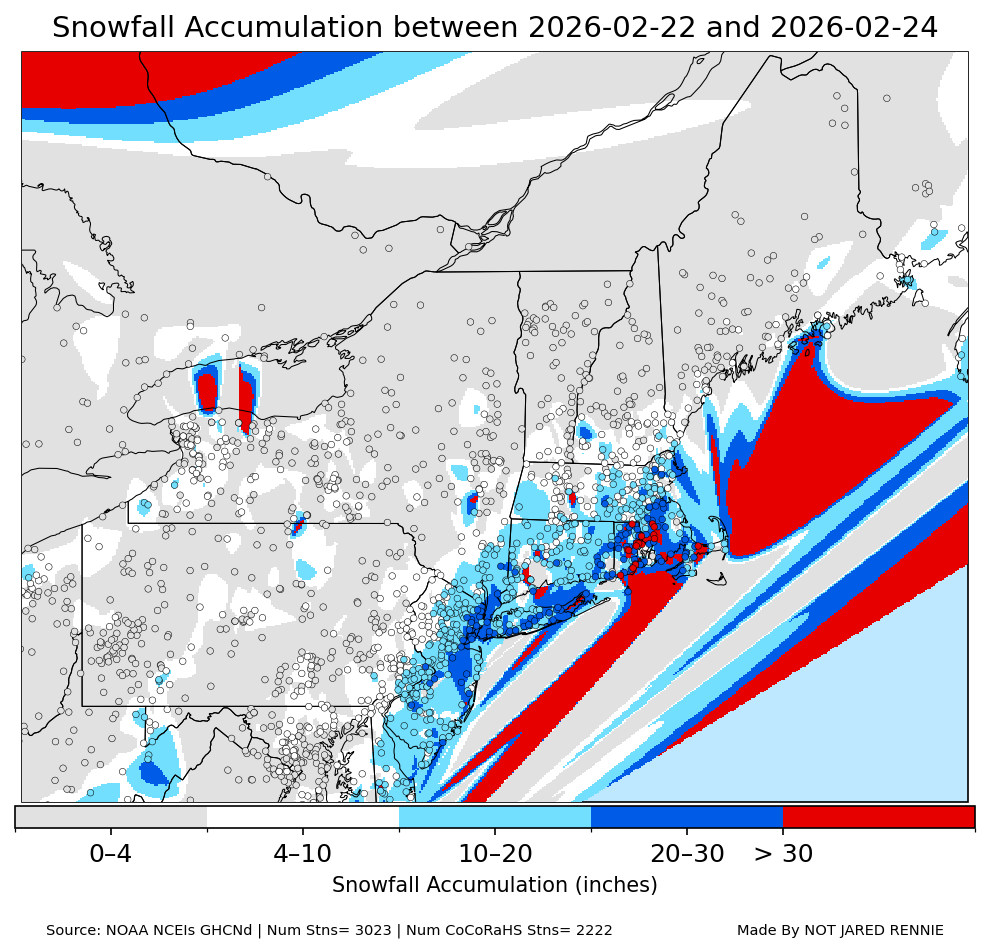

In [11]:
print('PLOTTING (Northeast US, Interpolated)')

#################################################
# CREATE FIGURE AND AXES
fig = plt.figure(num=1, figsize=(8, 5), dpi=dpi, facecolor='w', edgecolor='k')

# CONUS
conus_ax = fig.add_axes([0, 0, 1, 1], projection=ccrs.Mercator())
conus_ax.set_facecolor(ocean_hex)
conus_ax.spines['geo'].set_edgecolor(edgecolor)
conus_ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.Geodetic())

# Add Additional Features
conus_ax.add_feature(cfeature.LAND, linewidth=0.5, facecolor=land_hex, edgecolor=edgecolor, zorder=3)
conus_ax.add_feature(cfeature.LAKES, linewidth=0.5, facecolor=ocean_hex, edgecolor=edgecolor, zorder=4)
conus_ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor=edgecolor, zorder=10)

# Plot interpolated snowfall with discrete bins
intCONUS = conus_ax.pcolormesh(grid_lon, grid_lat, grid_snow,cmap=cmap, 
                               norm=norm,shading='auto',transform=ccrs.PlateCarree(),zorder=9)

# Add stations as points
scCONUS = conus_ax.scatter(finalData['LON'],finalData['LAT'],c=finalData['SNOW_SUM'],
                      cmap=cmap,norm=norm,s=10,transform=ccrs.PlateCarree(),edgecolors='black',
                      linewidths=0.25,zorder=10)

# Add legend
cax = fig.add_axes([0.1, -0.035, 0.8, 0.03])
cbar=plt.colorbar(scCONUS, cax=cax,orientation='horizontal',spacing='uniform')
cbar.set_ticks([2, 7, 15, 25, 50])
cbar.set_ticklabels(["0–4","4–10","10–20","20–30","> 30"])
cbar.set_label("Snowfall Accumulation (inches)",size=10)
cbar.ax.tick_params(labelsize=12)

# Add Titles
plt.suptitle(str(outTitle),size=14,color='black',y=1.05)
conus_ax.annotate('Source: NOAA NCEIs GHCNd | Num Stns= '+str(numStns_ALL)+' | Num CoCoRaHS Stns= '+str(numStns_COCORAHS),xy=(0.025, -0.18), xycoords='axes fraction', fontsize=7,color='black',horizontalalignment='left', verticalalignment='bottom')
conus_ax.annotate('Made By '+author,xy=(0.975, -0.18), xycoords='axes fraction', fontsize=7,color='black',horizontalalignment='right', verticalalignment='bottom')
plt.show()

Messy right? Let's try and clip out weird data over the ocean using a US state shapefile that's provided in this notebook. We will also not plot the original dots this time (commented out in case you want to compare)

In [12]:
%%time
# Build xarray and set coordinates (lat,lon)
da = xr.DataArray(grid_snow,
    dims=("lat", "lon"),
    coords={"lat": grid_lat[:, 0],"lon": grid_lon[0, :]},
    name="snow"
)
da = da.rio.set_spatial_dims(x_dim="lon", y_dim="lat")
da = da.rio.write_crs("EPSG:4326")

# Read in State Shapefile
states = gpd.read_file("./input_shapefile/cb_2022_us_state_500k.shp")
states = states.to_crs("EPSG:4326")
states = states[~states["STUSPS"].isin(["AK", "HI", "PR"])]

# Clip and Cleanup
da_masked = da.rio.clip(states.geometry,states.crs,drop=False)
da_masked = da_masked.assign_coords(
    lat=("lat", grid_lat[:, 0]),
    lon=("lon", grid_lon[0, :])
)
grid_snow = da_masked.values
grid_snow

CPU times: user 281 ms, sys: 40.1 ms, total: 321 ms
Wall time: 320 ms


array([[1.65095539, 1.82385213, 2.0177284 , ...,        nan,        nan,
               nan],
       [1.52655024, 1.7117006 , 1.92003126, ...,        nan,        nan,
               nan],
       [1.52899949, 1.72845508, 1.95188853, ...,        nan,        nan,
               nan],
       ...,
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan]])

PLOTTING (Northeast US, Interpolated, Clipped)


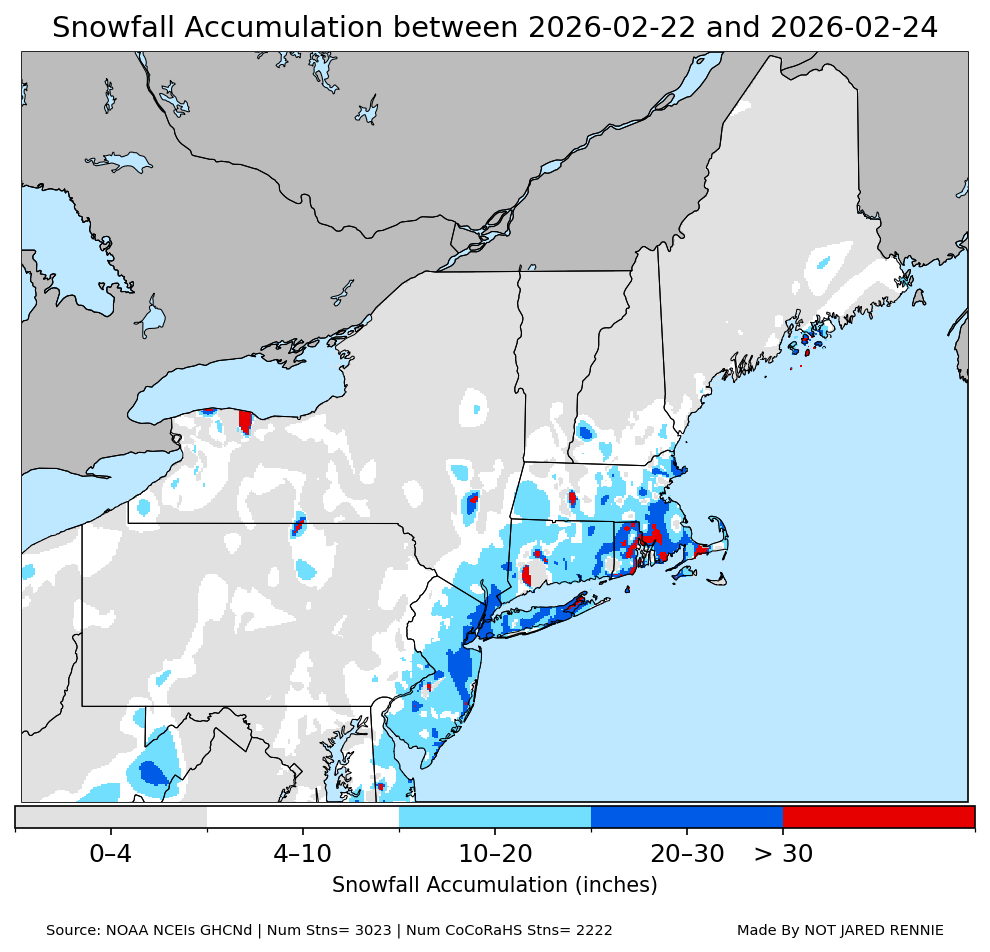

In [13]:
print('PLOTTING (Northeast US, Interpolated, Clipped)')

#################################################
# CREATE FIGURE AND AXES
fig = plt.figure(num=1, figsize=(8, 5), dpi=dpi, facecolor='w', edgecolor='k')

# CONUS
conus_ax = fig.add_axes([0, 0, 1, 1], projection=ccrs.Mercator())
conus_ax.set_facecolor(ocean_hex)
conus_ax.spines['geo'].set_edgecolor(edgecolor)
conus_ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.Geodetic())

# Add Additional Features
conus_ax.add_feature(cfeature.LAND, linewidth=0.5, facecolor=land_hex, edgecolor=edgecolor, zorder=3)
conus_ax.add_feature(cfeature.LAKES, linewidth=0.5, facecolor=ocean_hex, edgecolor=edgecolor, zorder=4)
conus_ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor=edgecolor, zorder=10)

# Plot interpolated snowfall with discrete bins
intCONUS = conus_ax.pcolormesh(grid_lon, grid_lat, grid_snow,cmap=cmap, 
                               norm=norm,shading='auto',transform=ccrs.PlateCarree(),zorder=9)

# Add stations as points
#scCONUS = conus_ax.scatter(finalData['LON'],finalData['LAT'],c=finalData['SNOW_SUM'],
#                      cmap=cmap,norm=norm,s=10,transform=ccrs.PlateCarree(),edgecolors='black',
#                      linewidths=0.25,zorder=10)

# Add legend
cax = fig.add_axes([0.1, -0.035, 0.8, 0.03])
cbar=plt.colorbar(scCONUS, cax=cax,orientation='horizontal',spacing='uniform')
cbar.set_ticks([2, 7, 15, 25, 50])
cbar.set_ticklabels(["0–4","4–10","10–20","20–30","> 30"])
cbar.set_label("Snowfall Accumulation (inches)",size=10)
cbar.ax.tick_params(labelsize=12)

# Add Titles
plt.suptitle(str(outTitle),size=14,color='black',y=1.05)
conus_ax.annotate('Source: NOAA NCEIs GHCNd | Num Stns= '+str(numStns_ALL)+' | Num CoCoRaHS Stns= '+str(numStns_COCORAHS),xy=(0.025, -0.18), xycoords='axes fraction', fontsize=7,color='black',horizontalalignment='left', verticalalignment='bottom')
conus_ax.annotate('Made By '+author,xy=(0.975, -0.18), xycoords='axes fraction', fontsize=7,color='black',horizontalalignment='right', verticalalignment='bottom')
plt.show()

It's better, but not the greatest. It only gets worse if you remove stations in the analysis. Remember when we looked at the different networks: 

In [14]:
print("Number of Stations Used: ",numStns_ALL)
print("Number of CoCoRaHS Stations Used: ",numStns_COCORAHS)
print("Number of COOP Stations Used: ",numStns_COOP)
print("Number of WBAN Stations Used: ",numStns_WBAN)

Number of Stations Used:  3023
Number of CoCoRaHS Stations Used:  2222
Number of COOP Stations Used:  708
Number of WBAN Stations Used:  93


What if we removed a network like CoCoRaHS or COOP? The results would be different. 

There is another option, but it comes with its own caveats.

# Part 2: Analysis of Gridded Observations using NOHRSC <a class="anchor" id="fourth-bullet"></a>
There is another option to use gridded data from the <a href='http://www.nohrsc.noaa.gov' target='_blank'> National Operational Hydrologic Remote Sensing Center (NOHRSC) </a>. They take into account the data above, along with some other physical considerations

From their <a href='https://www.nohrsc.noaa.gov/technology/pdf/PDD_National_Gridded_Snowfall_Analysis.pdf' target='_blank'> Product Description Document</a>: 

> The National Gridded Snowfall Analysis is generated by
assimilating observations from Cooperative observers, Community Collaborative Rain, Hail and
Snow Network observers and NWS spotter reports into a 24-hour background analysis based
on Stage IV qualitative precipitation estimates, with contributions from High Resolution Rapid
Refresh quantitative precipitation forecasts, the National Snow Analysis 2-meter air temperature
grids, and a novel gridded snowfall-to-liquid ratio climatology. The program that generates the
National Gridded Snowfall Analysis is repeated hourly for 5 days following the analysis time to
capture any late reported snowfall reports and includes several automated and manual options
for Quality Assurance on snowfall reports.
>
>The 24-hour background analysis is conducted using High Resolution Rapid Refresh F003
snow:precipitation ratio, Stage IV Quantitative Precipitation Estimate (QPE; when available),
and a climatological snowfall to liquid ratio (SLR) based on Global Historical Climatology
Network daily (GHCN-D). GHCN-D snowfall and precipitation, precipitation, and temperature 
data are used to generate a 30-year snowfall-to-liquid ratio climatology and 15-year snowfalltemperature thresholds for error detection and correction which are regenerated annually. Two
assimilation passes using ordinary kriging are used with the first pass addressing the log-ratio of
background to observed snowfall to correct biases and a second pass which addresses the first
pass minus observed differences.
>
>All assimilation kriging passes employ spherical semivariogram functions fitted to empirical
semivariograms. The system incorporates automated quality control including data consistency
and outlier checks during assimilation passes.

So good news bad news
- Good news: This solves a lot of the interpolation issues mentioned above
- Bad news: <a href='https://www.nohrsc.noaa.gov/snowfall_v2/data/' target='=blank'>Data</a> only goes back to October 2008.
- More bad news: Data is not in the cloud, so we have to download it.
- Even more bad news: No Alaska Data

So let's pick a day (or range of dates) and plot the 24 hour summary. Note that the results will be ending on the end date selected at 12 UTC

In [15]:
start_date='2026-02-22'
end_date='2026-02-24' 

### Download Data For Dates Requested

In [16]:
snow_directory="https://www.nohrsc.noaa.gov/snowfall_v2/data"
out_directory="./input_nohrsc"

# Create list of dates
dates = pd.date_range(start=start_date, end=end_date, freq='D')

for date in dates:
    print(
        date)
    # Format date as YYYYMMDD
    inTime = date.strftime('%Y%m%d') + '12'
    yearmonth = inTime[:6]

    # Construct file name
    inFile = f"sfav2_CONUS_24h_{inTime}.nc"
    print("\nDOWNLOAD:    " + inFile)
    FILE = os.path.join(out_directory, inFile)

    # Download if file doesn't exist
    if os.path.isfile(FILE):
        print("    File Already Exists.")
    else:
        url = f"{snow_directory}/{yearmonth}/{inFile}"
        print(f"    {url}")

        try:
            with requests.get(url, auth=('anonymous', 'pass'), stream=True) as r:
                r.raise_for_status()
                with open(FILE, 'wb') as f:
                    for chunk in r.iter_content(chunk_size=8192):
                        if chunk:
                            f.write(chunk)
            print("    Download complete!")
        except requests.HTTPError as e:
            print(f"    ERROR: Failed to download {inFile}")
            print("    ", e)

2026-02-22 00:00:00

DOWNLOAD:    sfav2_CONUS_24h_2026022212.nc
    https://www.nohrsc.noaa.gov/snowfall_v2/data/202602/sfav2_CONUS_24h_2026022212.nc
    Download complete!
2026-02-23 00:00:00

DOWNLOAD:    sfav2_CONUS_24h_2026022312.nc
    https://www.nohrsc.noaa.gov/snowfall_v2/data/202602/sfav2_CONUS_24h_2026022312.nc
    Download complete!
2026-02-24 00:00:00

DOWNLOAD:    sfav2_CONUS_24h_2026022412.nc
    https://www.nohrsc.noaa.gov/snowfall_v2/data/202602/sfav2_CONUS_24h_2026022412.nc
    Download complete!


## Read in Data For Dates

In [17]:
# List to store daily datasets
daily_datasets = []

for date in dates:
    inTime = date.strftime('%Y%m%d') + '12'
    infile = os.path.join(out_directory, f"sfav2_CONUS_24h_{inTime}.nc")
    print('READING IN DAILY DATA: ', infile)
    
    if not os.path.isfile(infile):
        sys.exit(f"\tERROR: File {infile} Does Not Exist, Exiting")
    
    try:
        ds = xr.open_dataset(infile)
        daily_datasets.append(ds['Data'])  # Replace 'sfav2' with actual variable name in your file
        print("SUCCESS")
    except Exception as e:
        sys.exit(f"\tERROR: Failed to read {infile}\n{e}")

# Combine all daily data along a new "time" dimension
combined = xr.concat(daily_datasets, dim='time')
lats=combined.lat.values
lons=combined.lon.values

# Sum along the "time" dimension to get total snowfall
total_snow = combined.sum(dim='time')
total_snow

READING IN DAILY DATA:  ./input_nohrsc/sfav2_CONUS_24h_2026022212.nc
SUCCESS
READING IN DAILY DATA:  ./input_nohrsc/sfav2_CONUS_24h_2026022312.nc
SUCCESS
READING IN DAILY DATA:  ./input_nohrsc/sfav2_CONUS_24h_2026022412.nc
SUCCESS


<xarray.DataArray 'Data' (lat: 850, lon: 1500)> Size: 5MB
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)
Coordinates:
  * lat      (lat) float64 7kB 54.98 54.94 54.9 54.86 ... 21.14 21.1 21.06 21.02
  * lon      (lon) float64 12kB -126.0 -125.9 -125.9 ... -66.1 -66.06 -66.02
Attributes: (12/15)
    institution:             Office of Water Prediction
    gisrs_product_code:      623
    long_name:               snowfall accumulation
    standard_name:           thickness_of_snowfall_amount
    satellite_data:          no
    thematic:                no
    ...                      ...
    no_data_value:           -99999.0
    minimum_data_value:      0.0
    maximum_data_value:      0.4338111
    start_date:              2026-02-21 12:00:00 UTC
    stop_date:               2026-02-22 12:00:00 UTC
    grid_mapping:            crs

Let's convert to inches AND feet, and get some stats.

In [18]:
# Convert m to ft
total_snow_feet=(total_snow.values * 3.28084)

# Convert m to inches
total_snow_inches=(total_snow.values * 39.3701)

value_max="%.1f" % np.nanmax(total_snow_feet[np.nonzero(total_snow_feet)])
value_min="%.1f" % np.nanmin(total_snow_feet[np.nonzero(total_snow_feet)])

out_min="%.1f Inches" % np.nanmax(total_snow_inches[np.nonzero(total_snow_inches)])
out_max="%.1f Inches" % np.nanmin(total_snow_inches[np.nonzero(total_snow_inches)])

if float(value_max) < 1:
    value_max="%.1f" % np.nanmax(total_snow_inches[np.nonzero(total_snow_inches)])
    if float(value_max) < 0.1:
        value_max="%.1f" % (0.1)
    out_max=value_max+' Inches'
else:
    out_max=value_max+' Feet'
if float(value_min) < 1:
    value_min="%.1f" % np.nanmin(total_snow_inches[np.nonzero(total_snow_inches)])
    if float(value_min) < 0.1:
        value_min="%.1f" % (0.1)
    out_min=value_min+' Inches'
else:
    out_min=value_min+' Feet'
print('\t MIN: ',out_min,' | MAX: ',out_max)

	 MIN:  0.1 Inches  | MAX:  4.1 Feet


## Plot Data

PLOTTING (CONUS)


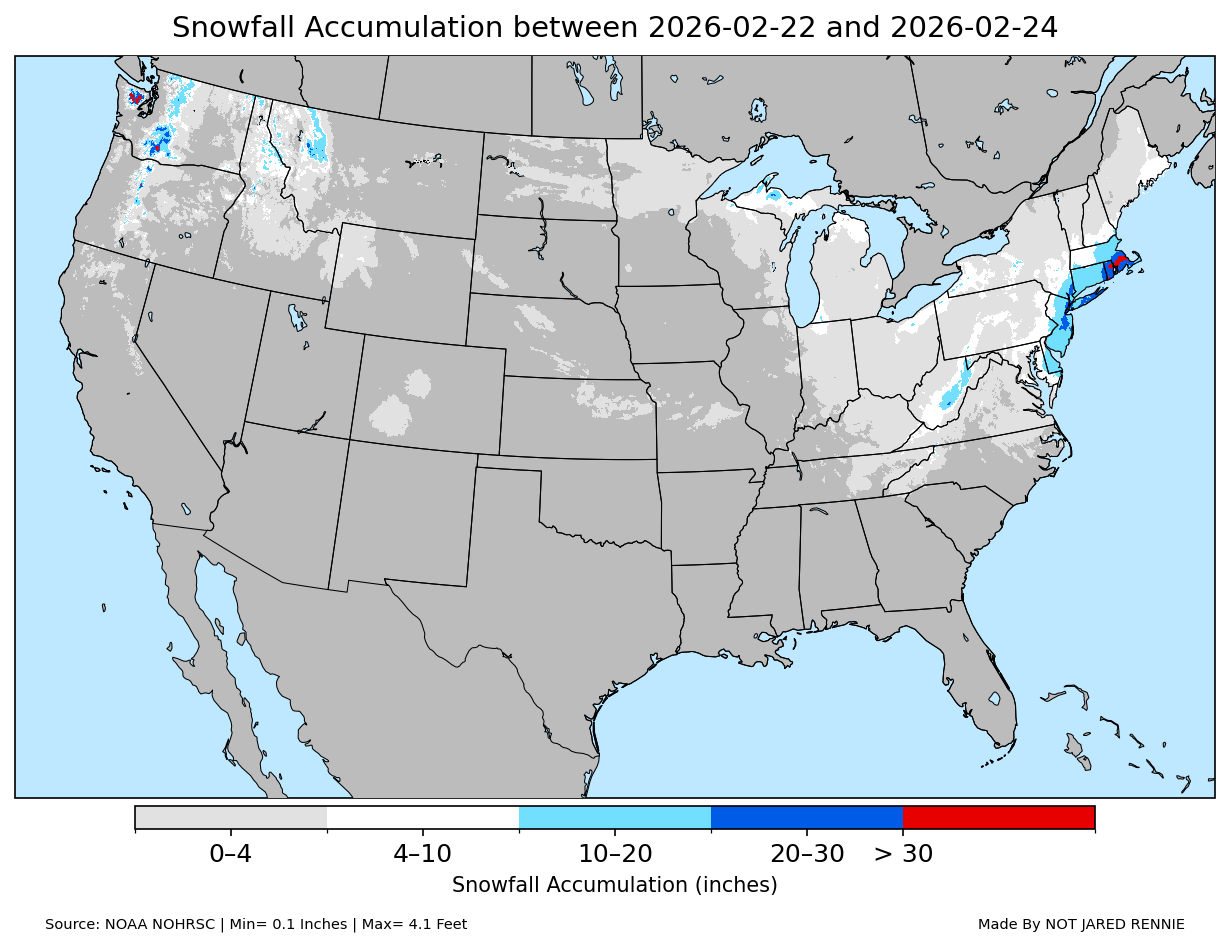

CPU times: user 2.27 s, sys: 240 ms, total: 2.51 s
Wall time: 2.3 s


In [19]:
%%time

print('PLOTTING (CONUS)')
#################################################
# PLOTTING SETTINGS
dpi = 150
land_hex='#bcbcbc'  # ESRI Light Gray Canvas
ocean_hex='#bee8ff' # ESRI Light Gray Canvas
edgecolor = 'black'

if start_date == end_date:
    outTitle = f'Snowfall Accumulation on {end_date}'
else:
    outTitle = f'Snowfall Accumulation between {start_date} and {end_date}'
    
#################################################
# CREATE FIGURE AND AXES
fig = plt.figure(num=1, figsize=(8, 5), dpi=dpi, facecolor='w', edgecolor='k')

# CONUS
conus_ax = fig.add_axes([0, 0, 1, 1], projection=ccrs.LambertConformal())
conus_ax.set_facecolor(ocean_hex)
conus_ax.spines['geo'].set_edgecolor(edgecolor)
conus_ax.set_extent([-120, -73, 22, 50], crs=ccrs.Geodetic())

# Add Additional Features
conus_ax.add_feature(cfeature.LAND, linewidth=0.5, facecolor=land_hex, edgecolor=edgecolor, zorder=3)
conus_ax.add_feature(cfeature.LAKES, linewidth=0.5, facecolor=ocean_hex, edgecolor=edgecolor, zorder=4)
conus_ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor=edgecolor, zorder=10)

# Plot Gridded Data
vals_nonmiss=ma.masked_where(total_snow_inches <= 0, total_snow_inches)
intCONUS=conus_ax.pcolormesh(lons, lats, vals_nonmiss,transform=ccrs.PlateCarree(),cmap=cmap,norm=norm,zorder=9)

# Add legend
cax = fig.add_axes([0.1, -0.035, 0.8, 0.03])
cbar=plt.colorbar(scCONUS, cax=cax,orientation='horizontal',spacing='uniform')
cbar.set_ticks([2, 7, 15, 25, 50])
cbar.set_ticklabels(["0–4","4–10","10–20","20–30","> 30"])
cbar.set_label("Snowfall Accumulation (inches)",size=10)
cbar.ax.tick_params(labelsize=12)

# Add Titles
plt.suptitle(str(outTitle),size=14,color='black',y=1.05)
conus_ax.annotate('Source: NOAA NOHRSC | Min= '+str(out_min)+' | Max= '+str(out_max),xy=(0.025, -0.18), xycoords='axes fraction', fontsize=7,color='black',horizontalalignment='left', verticalalignment='bottom')
conus_ax.annotate('Made By '+author,xy=(0.975, -0.18), xycoords='axes fraction', fontsize=7,color='black',horizontalalignment='right', verticalalignment='bottom')
plt.show()

And let's zoom in on the Northeast One more time:

PLOTTING (Northeast)


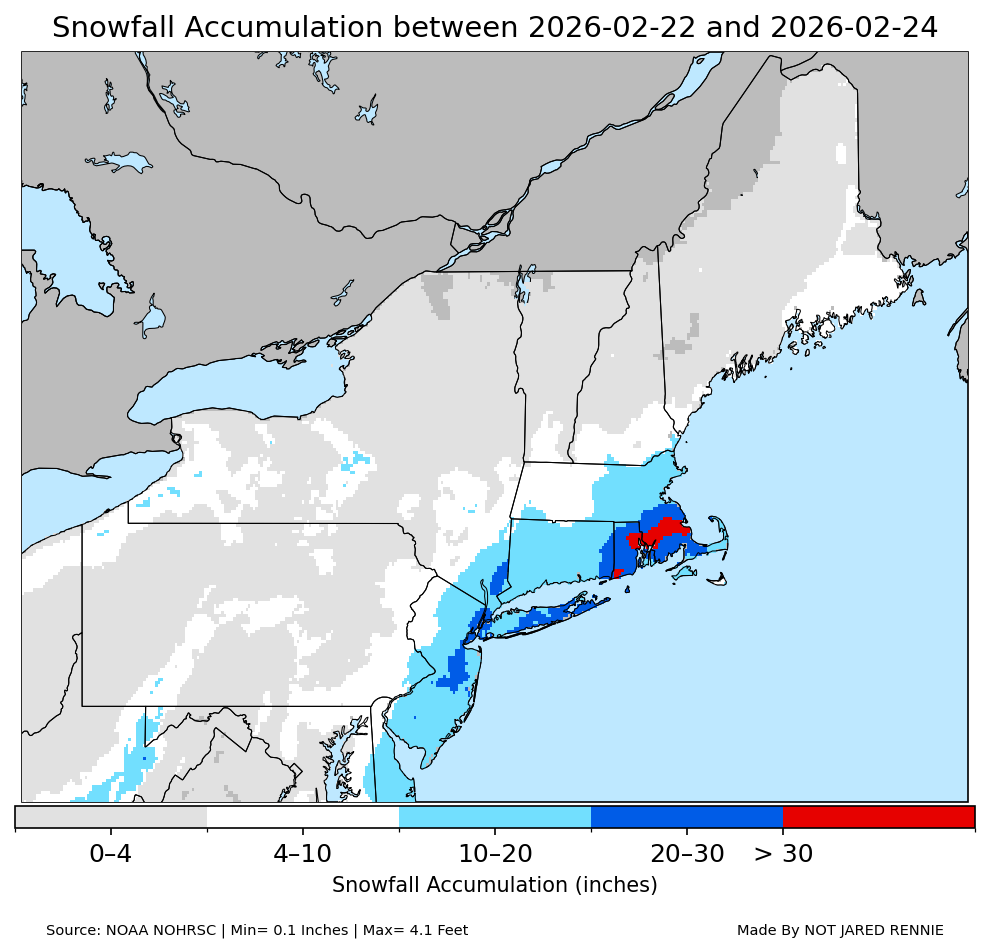

CPU times: user 2.06 s, sys: 220 ms, total: 2.28 s
Wall time: 2.06 s


In [20]:
%%time

print('PLOTTING (Northeast)')
    
#################################################
# CREATE FIGURE AND AXES
fig = plt.figure(num=1, figsize=(8, 5), dpi=dpi, facecolor='w', edgecolor='k')

# CONUS
conus_ax = fig.add_axes([0, 0, 1, 1], projection=ccrs.Mercator())
conus_ax.set_facecolor(ocean_hex)
conus_ax.spines['geo'].set_edgecolor(edgecolor)
conus_ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.Geodetic())

# Add Additional Features
conus_ax.add_feature(cfeature.LAND, linewidth=0.5, facecolor=land_hex, edgecolor=edgecolor, zorder=3)
conus_ax.add_feature(cfeature.LAKES, linewidth=0.5, facecolor=ocean_hex, edgecolor=edgecolor, zorder=4)
conus_ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor=edgecolor, zorder=10)

# Plot Gridded Data
vals_nonmiss=ma.masked_where(total_snow_inches <= 0, total_snow_inches)
conus_ax.pcolormesh(lons, lats, vals_nonmiss,transform=ccrs.PlateCarree(),cmap=cmap,norm=norm,zorder=9)

# Add legend
cax = fig.add_axes([0.1, -0.035, 0.8, 0.03])
cbar=plt.colorbar(scCONUS, cax=cax,orientation='horizontal',spacing='uniform')
cbar.set_ticks([2, 7, 15, 25, 50])
cbar.set_ticklabels(["0–4","4–10","10–20","20–30","> 30"])
cbar.set_label("Snowfall Accumulation (inches)",size=10)
cbar.ax.tick_params(labelsize=12)

# Add Titles
plt.suptitle(str(outTitle),size=14,color='black',y=1.05)
conus_ax.annotate('Source: NOAA NOHRSC | Min= '+str(out_min)+' | Max= '+str(out_max),xy=(0.025, -0.18), xycoords='axes fraction', fontsize=7,color='black',horizontalalignment='left', verticalalignment='bottom')
conus_ax.annotate('Made By '+author,xy=(0.975, -0.18), xycoords='axes fraction', fontsize=7,color='black',horizontalalignment='right', verticalalignment='bottom')
plt.show()

SNOMG!!!! 

**Congrats on completing this notebook! Now go forth and make better plots!**